In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

#dp = Package("datapackage.json")
# dp = Package("/Users/romain/GitHub/premise/dev/trails_2026-01-07.zip")
dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-31.zip")
trails = Trails(dp, interpolate_annual=True)

methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
#methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [ ]:
%%time

ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=27827,
    methods=methods,
    max_depth=1,
    #max_depth=4,
    show_progress=True,
    min_amount=1e-22,
    attribute_to_roots=True,
    #parallel_years=False,
    compute_score=True,
    store_inventory=False,
    debug=False
)

Temporal LCA: solve years:  58%|████████      | 11/19 [00:30<00:22,  2.82s/year]

In [ ]:
ref_year = 2050
trails.static_lca(
    year=ref_year,
    act_idx=27827,
    methods=methods,
)

In [ ]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [3]:
trails.scores

Format,coo
Data Type,float32
Shape,"(37803, 325, 37803)"
nnz,467687
Density,1.0069766605830694e-06
Read-only,True
Size,12.5M
Storage ratio,0.00


In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

#dp = Package("datapackage.json")
# dp = Package("/Users/romain/GitHub/premise/dev/trails_2026-01-07.zip")
dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-31.zip")
trails = Trails(dp, interpolate_annual=True)

methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
#methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [2]:
%%time

ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=27827,
    methods=methods,
    #max_depth=1,
    max_depth=4,
    show_progress=True,
    min_amount=1e-22,
    attribute_to_roots=True,
    parallel_years=True,
    debug=False
)

Temporal LCA: solve years: 100%|████████████| 141/141 [11:03<00:00,  4.70s/year]


CPU times: user 28min 23s, sys: 1min 25s, total: 29min 48s
Wall time: 12min 54s


In [3]:
ref_year = 2050
trails.static_lca(
    year=ref_year,
    act_idx=27827,
    methods=methods,
)

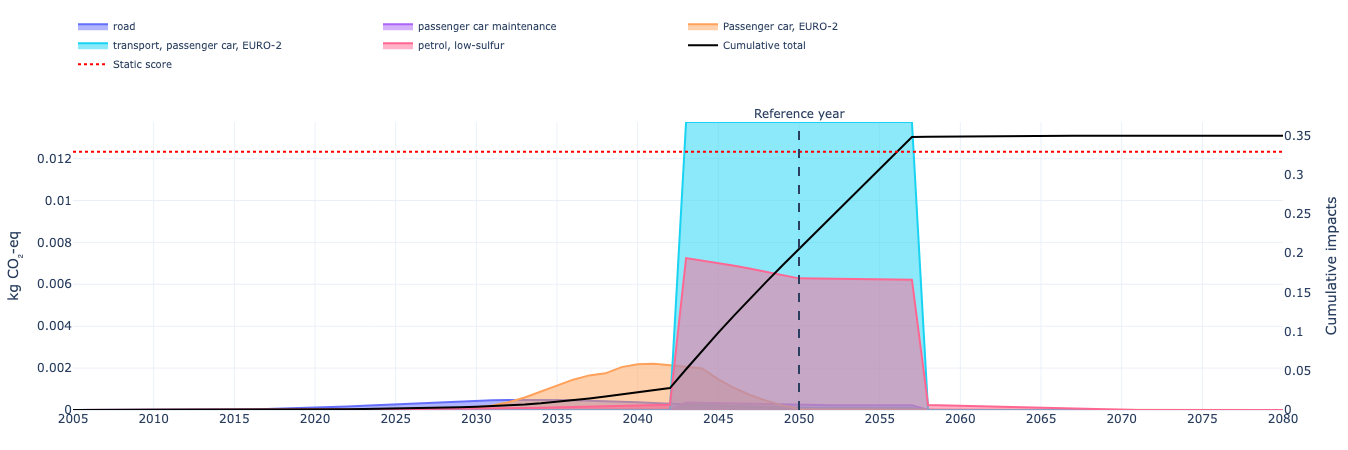

In [4]:
fig = plot_temporal_scores(
    results_by_year=trails.characterized_inventory,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()